<a href="https://colab.research.google.com/github/soutbox/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_7%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 오픈소스 기반 데이터 분석 7강 - 데이터 전처리 2

### 7-1 데이터 결측치 찾기

In [31]:
import pandas as pd
import numpy as np

"""
======================================================
[Pandas 핵심 개념 정리: shape 속성과 axis 매개변수]
======================================================

1. shape 속성 (Attribute)
- 용도: DataFrame의 크기(차원)를 확인할 때 사용.
- 특징: 메소드가 아닌 속성이므로 끝에 괄호()를 붙이지 않음.
- 반환 형태: 항상 길이가 2인 튜플(Tuple) 형태 -> (행의 수, 열의 수)
- 사용 예시:
    * df.shape     # 예: (5, 4) 반환
    * df.shape[0]  # 튜플의 0번째 값 -> 전체 행(Row)의 수 반환
    * df.shape[1]  # 튜플의 1번째 값 -> 전체 열(Column)의 수 반환

[!] 주의사항 (IndexError 원인)
- df.shape[3]을 하면 3번 인덱스(4번째) 열이 나오는 것이 아님!
- shape는 단지 (행, 열) 숫자 2개만 들어있는 튜플이므로, 인덱스는 0과 1만 존재함.
- 특정 열의 '데이터'를 추출하려면 위치 기반 인덱서인 iloc를 사용해야 함.
    * 올바른 데이터 추출법: df.iloc[:, 3] 또는 df['열이름']


2. 집계 함수의 axis (축) 매개변수 원리
- 판다스의 sum(), mean() 등 집계 메소드들은 연산 방향을 정하는 axis 매개변수가 있음.
- 작동 방식:
    * axis=0 (기본값): 행(Row)을 따라 아래로 이동하며 연산
      -> 결과적으로 "각 열(Column)별" 합계가 나옴.
    * axis=1: 열(Column)을 따라 우측으로 이동하며 연산
      -> 결과적으로 "각 행(Row)별" 합계가 나옴.

[?] 왜 axis=0 (열별 집계)이 기본값일까?
- 데이터 분석 관례상 열(Column)은 '변수(특성)', 행(Row)은 '개별 관측치'를 의미함.
- "나이의 평균은?", "점수의 결측치 개수는?"처럼 각 '변수(열) 단위'로
  데이터를 집계하는 것이 압도적으로 흔하기 때문에 판다스가 이를 기본값으로 설정함.
"""

data = {'이름': ['김철수', '이영희', '박민수', '최지훈', '정소희'],
        '나이': [25, 30, np.nan, 22, 35],
        '도시': ['서울', None, '인천', '서울', '대전'],
        '점수': [90, 85, np.nan, 80, 92]}

df = pd.DataFrame(data)

## 결측치 여부 확인
df.isnull() #
df.isna() # numpy 활용

## 열별, 행별 결측치 개수 확인
df.isnull().sum()
df.isnull().sum(axis=1) # 축방향변경

## 특정 열, 행 결측치 확인
df[df.isnull().any(axis=1)]
df[df['나이'].isnull()]

## 결측치가 아닌 항목 확인
df.notnull()

## 결측치 비율
## 결측치 비율 확인 (%)
# [1] df.isnull().sum().sum(): DataFrame 전체 결측치의 총 개수
#     - 첫 번째 .sum()은 각 열별 결측치 개수를 구하고, 두 번째 .sum()은 그 값을 모두 더함
# [2] df.shape[0]: 전체 행의 수
# [3] df.shape[1]: 전체 열의 수
# [4] (df.shape[0] * df.shape[1]): 행 수 x 열 수 = 전체 데이터(셀)의 총 개수
# [5] (전체 결측치 개수 / 전체 데이터 개수) * 100 = 최종 결측치 비율(%)
df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100




np.float64(15.0)

### 7-2 데이터 시각화를 이용한 결측치 찾기

In [22]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u

In [23]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

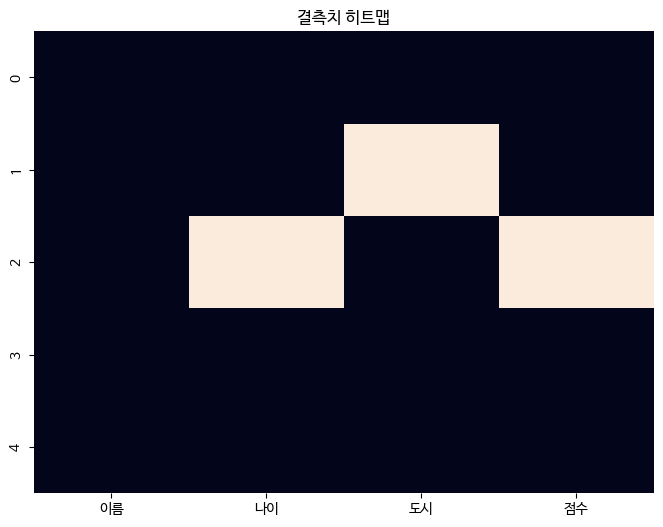

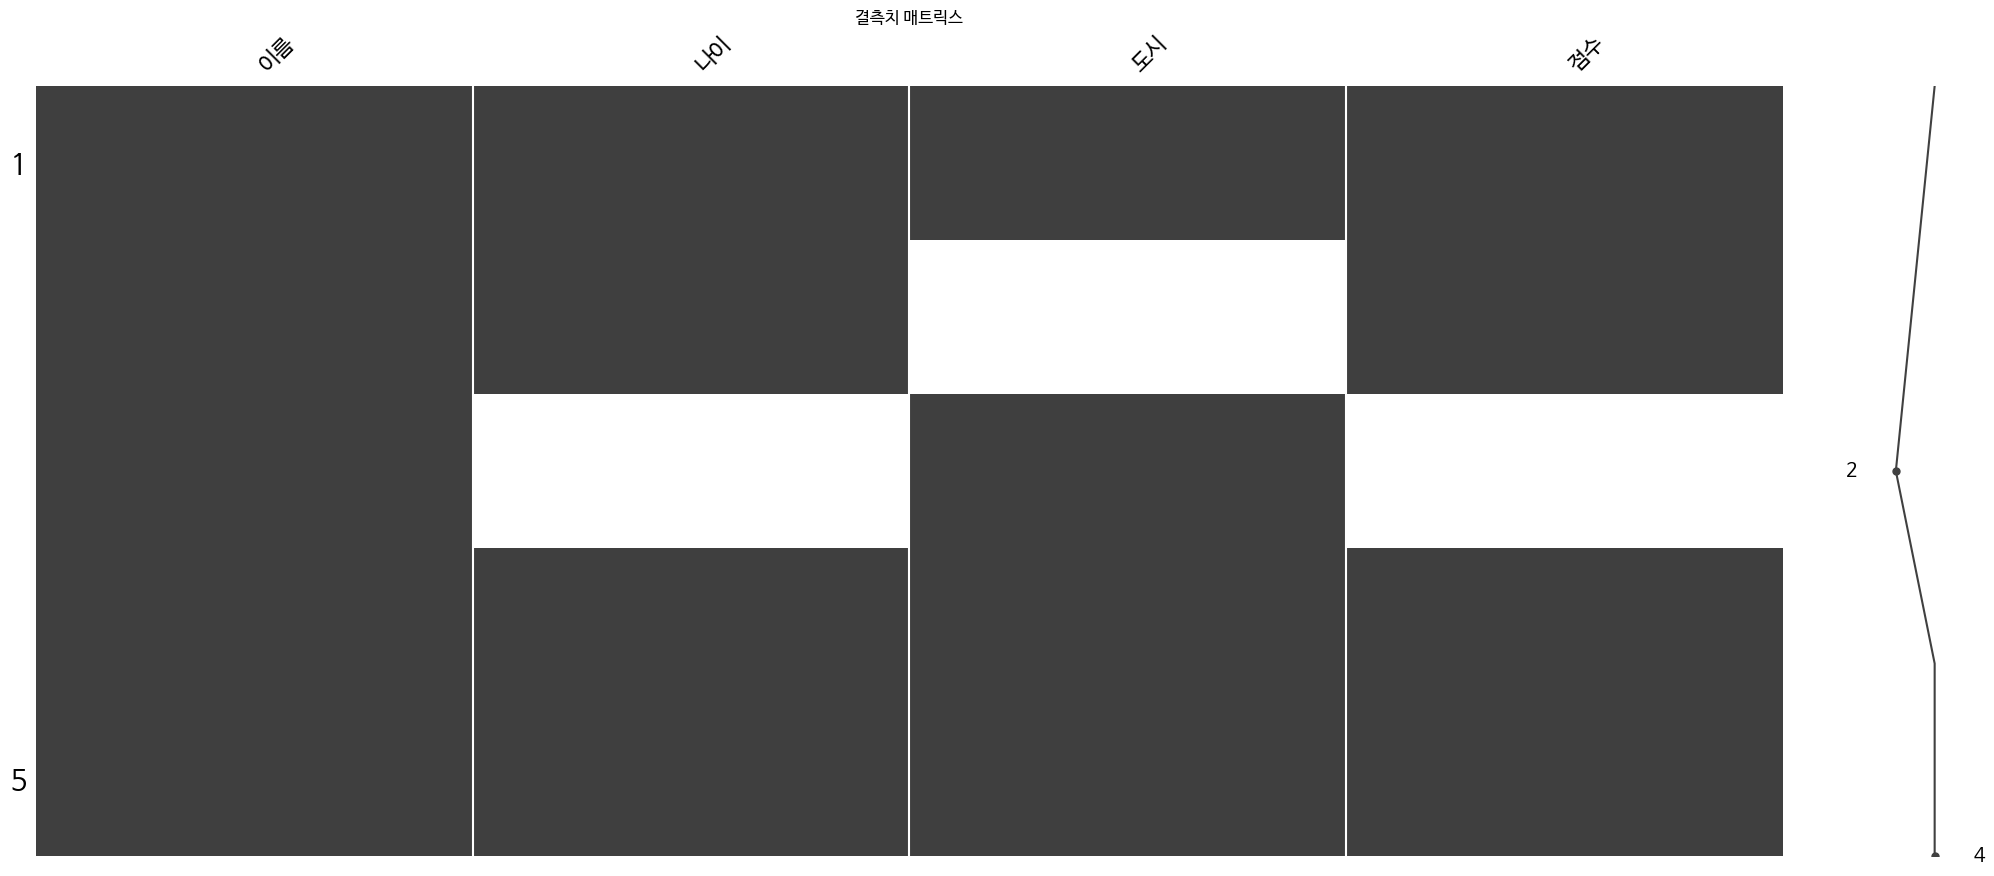

In [4]:
import numpy as np
import pandas as pd

### 시각화 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

data = {'이름': ['김철수', '이영희', '박민수', '최지훈', '정소희'],
        '나이': [25, 30, np.nan, 22, 35],
        '도시': ['서울', None, '인천', '서울', '대전'],
        '점수': [90, 85, np.nan, 80, 92]}
df = pd.DataFrame(data)

### 결측치 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("결측치 히트맵")
plt.show()

### 결측치 매트릭스
msno.matrix(df)
plt.title("결측치 매트릭스")
plt.show()

### 7-3 사분위 범위를 통한 이상치 찾기

In [1]:
import pandas as pd
import numpy as np

점수_데이터 = [72, 68, 75, 282, 64, 31, 78, 69, 88, 92, 22, 84, 61, -90, 130, 66]
학번_데이터 = list(range(1001, 1001 + len(점수_데이터)))

df = pd.DataFrame({
    '학번': 학번_데이터,
    '점수': 점수_데이터
})

### 사분위 범위 경계값 계산
q1 = df['점수'].quantile(0.25)
q3 = df['점수'].quantile(0.75)
iqr = q3 - q1

하한값 = q1 - 1.5 * iqr
상한값 = q3 + 1.5 * iqr


### IQR 통계량 출력
print(q1)
print(q3)
print(iqr)
print(하한값)
print(상한값)




63.25
85.0
21.75
30.625
117.625


### 7-4 Z-점수를 통한 이상치 찾기

In [ ]:
import pandas as pd
import numpy as np

점수_데이터 = [72, 68, 75, 282, 64, 31, 78, 69, 88, 92, 22, 84, 61, -90, 130, 66]
학번_데이터 = list(range(1001, 1001 + len(점수_데이터)))

df = pd.DataFrame({
    '학번': 학번_데이터,
    '점수': 점수_데이터
})

### Z-점수 계산
점수_평균 = df['점수'].mean()
점수_표준편차 =  df['점수'].std()
df['점수_Z'] = (df['점수'] - 점수_평균) / 점수_표준편차
df

### 임계값 설정 및 이상치 여부 판단
임계값 = 2
df['이상치여부'] = df['점수_Z'].abs() > 임계값

### 이상치 데이터 출력
df[df['이상치여부']]

### 이상치 비율 출력
df['이상치여부'].mean() * 100


np.float64(12.5)

### 7-5 평균값 및 선형보간법을 통한 결측치 처리

In [ ]:
import pandas as pd
import numpy as np

file_path = "raw_large_shopping_customer.csv"
df = pd.read_csv(file_path)
print(df.isnull().sum())

## ----------------------------------------------------------------------
## [결측치 제거: 다중 결측 행 삭제]
## ----------------------------------------------------------------------
# 현재 데이터는 'ID', '나이', '소득', '지출', '평균구매횟수'의 총 5개 열(Column)로 구성되어 있음.
# 따라서 df.shape[1] 은 5를 반환함.

# thresh 파라미터는 "최소한 몇 개의 정상 데이터(Non-NaN)가 있어야 행을 살릴 것인가?"를 정하는 임계값.
# thresh = df.shape[1] - 1
#        = 5 - 1
#        = 4

# [결론]
# 한 행(고객 1명)의 5개 데이터 중 정상 데이터가 최소 4개 이상이어야 살아남음.
# 즉, 결측치가 0개이거나 1개(예: ID 1번 고객처럼 소득만 누락된 경우)인 행은 보존하고,
# 결측치가 2개 이상 발생하여 데이터의 신뢰도가 크게 떨어지는 행은 통째로 삭제하는 코드.
df_cleaned = df.dropna(thresh=df.shape[1] - 1)


## ----------------------------------------------------------------------
## [결측치 대치 1: 평균값(Mean)으로 채우기]
## ----------------------------------------------------------------------
# [1] df_cleaned[['나이', '소득']].mean(): '나이'와 '소득' 열의 전체 평균값을 각각 계산함 (NaN 제외).
# [2] fillna(...): 계산된 평균값을 해당 열의 빈칸(NaN)에 일괄적으로 채워 넣음.
# [3] .loc[:, ['나이', '소득']] = ... : 처리된 결과를 원본 데이터프레임의 해당 열에 안전하게 덮어씀.
# (결과: 나이나 소득이 누락된 고객은 전체 고객의 평균 나이/소득 수치를 부여받게 됨)
df_cleaned.loc[:, ['나이', '소득']] = df_cleaned[['나이', '소득']].fillna(df_cleaned[['나이', '소득']].mean())


## ----------------------------------------------------------------------
## [결측치 대치 2: 선형 보간법(Linear Interpolation) 적용]
## ----------------------------------------------------------------------
# [1] interpolate(method='linear'): 빈칸(NaN)을 기준으로 바로 앞 행과 뒤 행의 값을 연결하는
#     직선을 그어, 그 중간에 위치할 적절한 예상 값을 수학적으로 계산해 채우는 방식.
# [2] 주로 값의 흐름이나 순서(예: 시간의 흐름, 금액의 점진적 변화)가 의미 있는 데이터에서
#     자연스럽게 빈칸을 메울 때 사용함.
df_cleaned.loc[:, ['지출', '평균구매횟수']] = df_cleaned[['지출', '평균구매횟수']].interpolate(method='linear')

df_cleaned.to_csv("cleaned_large_shopping_customer.csv", index=False, encoding="utf-8-sig")

ID         0
나이        50
소득        50
지출        50
평균구매횟수    50
dtype: int64


### 7-6 DataFrame 값 변경

In [ ]:
import pandas as pd

data = {'age': [25, 30, None, 22, 35],
        'city': ['Seoul', None, 'Incheon', 'Seoul', 'Daejeon'],
        'score': [90, 85, None, 80, 92]}
df = pd.DataFrame(data)

### replace를 이용한 Seoul -> 서울
df['city'] = df['city'].replace('Seoul', '서울')
# print(df)

### replace를 이용한 None -> 미정, Incheon -> 인천
df['city'] = df['city'].replace({'Incheon':'인천', None: '미정'})
# print(df)

### map을 이용한 값 변경
df = pd.DataFrame(data)
city_map = {'Seoul': '서울특별시', None: '미정', 'Incheon':'인천광역시', 'Daejeon':'대전광역시'}
df['city'] = df['city'].map(city_map)


### apply 함수를 이용한 값 변경
df['age_str'] = df['age'].map(lambda x: f"{x}살" if pd.notna(x) else "알수없음");
# print(df)

### apply 함수를 이용한 행단위 값 변경
def age_plus_score(row):
  age = row['age'] if pd.notna(row['age']) else 0
  score = row['score'] if pd.notna(row['score']) else 0
  return age + score

df['age_plus_score'] = df.apply(age_plus_score, axis=1)

### loc 인덱스를 이용한 값 변경
df.loc[df['score'] < 90, 'score'] = 90
print("\n점수가 90점 미만인 사람 90점으로 변경:\n", df)

### where 함수를 이용한 값 변경
df['age_where'] = df['age'].where(df['age']>=30, other=0)
print("\nage가 30이상인 값만 유지하고 나머지를 0으로 변경\n", df['age_where'])
df



점수가 90점 미만인 사람 90점으로 변경:
     age   city  score age_str  age_plus_score
0  25.0  서울특별시   90.0   25.0살           115.0
1  30.0     미정   90.0   30.0살           115.0
2   NaN  인천광역시    NaN    알수없음             0.0
3  22.0  서울특별시   90.0   22.0살           102.0
4  35.0  대전광역시   92.0   35.0살           127.0

age가 30이상인 값만 유지하고 나머지를 0으로 변경
 0     0.0
1    30.0
2     0.0
3     0.0
4    35.0
Name: age_where, dtype: float64


,age,city,score,age_str,age_plus_score,age_where
0,25.0,서울특별시,90.0,25.0살,115.0,0.0
1,30.0,미정,90.0,30.0살,115.0,30.0
2,NaN,인천광역시,NaN,알수없음,0.0,0.0
3,22.0,서울특별시,90.0,22.0살,102.0,0.0
4,35.0,대전광역시,92.0,35.0살,127.0,35.0


### 7-7 날짜 데이터 타입 다루기


In [ ]:
date_str = ['2025-07-01', '2025-08-01', '2025-09-01']
df_date = pd.DataFrame({'date_str':date_str})

### datetime 타입 변환
df_date['date'] = pd.to_datetime(df_date['date_str'])
df_date.info()

### 날짜 데이터 분리
print(df_date['date'].dt.year)
print(df_date['date'].dt.month)
print(df_date['date'].dt.day)
print(df_date['date'].dt.day_name())

### 날짜 데이터 포멧 변경
df_date['date_formatted'] = df_date['date'].dt.strftime('%Y/%m/%d')
df_date


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date_str  3 non-null      object        
 1   date      3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 180.0+ bytes
0    2025
1    2025
2    2025
Name: date, dtype: int32
0    7
1    8
2    9
Name: date, dtype: int32
0    1
1    1
2    1
Name: date, dtype: int32
0    Tuesday
1     Friday
2     Monday
Name: date, dtype: object


,date_str,date,date_formatted
0,2025-07-01,2025-07-01,2025/07/01
1,2025-08-01,2025-08-01,2025/08/01
2,2025-09-01,2025-09-01,2025/09/01


## 7-8 실습 시나리오 - 데이터 정제

### [재수행] 6-5 실습 시나리오 - Kaggle을 활용한 데이터 수집 및 측정

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"devgiju","key":"76de112570f5630847d4a303339c8fb6"}'}

In [19]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c store-sales-time-series-forecasting

!unzip store-sales-time-series-forecasting.zip

store-sales-time-series-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  store-sales-time-series-forecasting.zip
replace holidays_events.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace holidays_events.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: holidays_events.csv     
replace oil.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: oil.csv                 
  inflating: sample_submission.csv   
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               
  inflating: transactions.csv        


In [4]:
import pandas as pd

# Grocery Sales 데이터 DataFrame 로드
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
oil = pd.read_csv('oil.csv')
train = pd.read_csv('train.csv')
holidays_events = pd.read_csv('holidays_events.csv')

# 판매 데이터 살펴보기
train.info()

# 판매 데이터 기본 통계량
train.describe()

# 매장 데이터 기본 정보
stores.head()

# 원유 가격 데이터 기본 정보
oil.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


### 데이터 분포 시각화

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(train['sales'], bins=50)
plt.title("판매량 분포")
plt.xlabel("판매량")
plt.ylabel("빈도")
plt.xlim(0, 5000)
plt.show()

store_sales = train.groupby('store_nbr')['sales'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='store_nbr', y='sales', data=store_sales)
plt.title("매장별 평균 판매량")
plt.xlabel("매장 번호")
plt.ylabel("평균 판매량")
plt.xticks(rotation=90)
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>

### 결측치 처리

In [7]:
## 판매, 매장, 거래, 원유, 휴일이벤트 데이터 결측치
print(train.isnull().sum())
print(stores.isnull().sum())
print(transactions.isnull().sum())
print(oil.isnull().sum())
print(holidays_events.isnull().sum())


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64
date            0
store_nbr       0
transactions    0
dtype: int64
date           0
dcoilwtico    43
dtype: int64
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

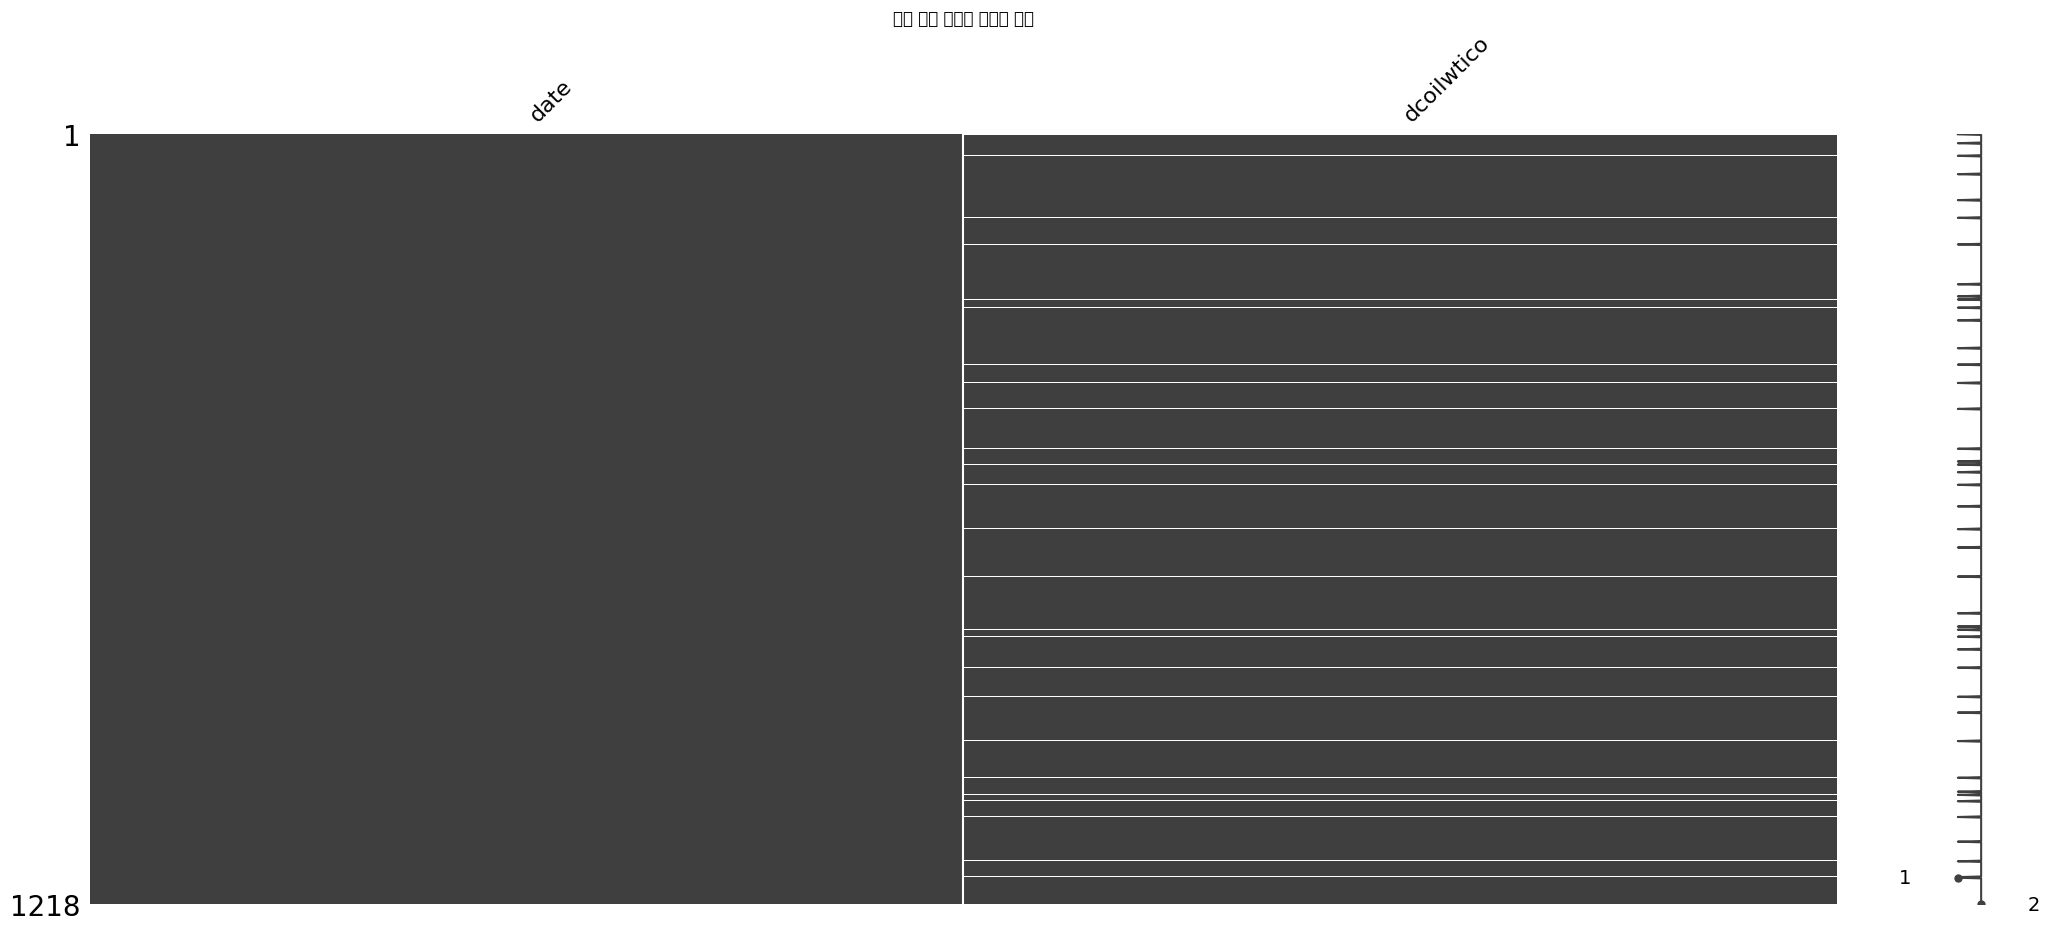

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

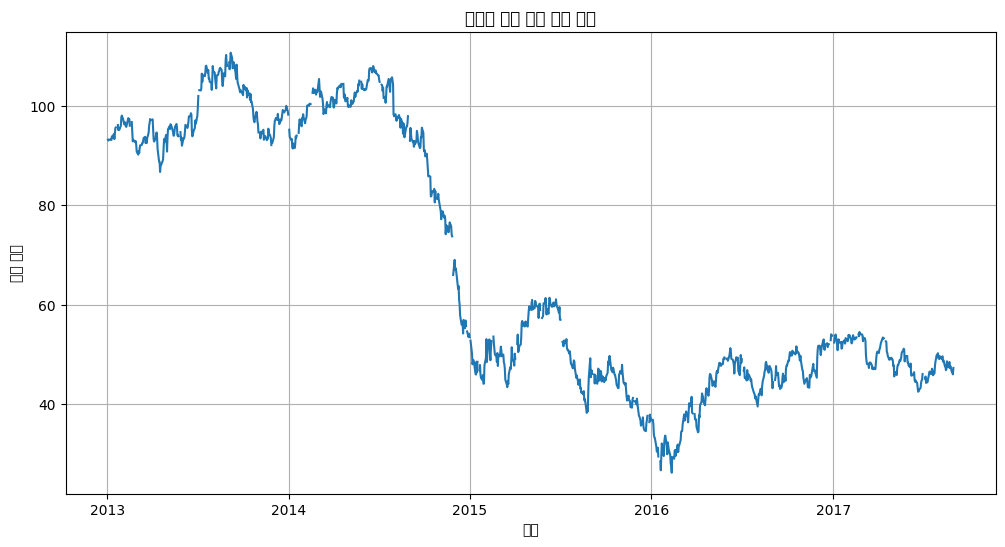

In [8]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(oil)
plt.title("원유 가격 데이터 결측치 분포")
plt.show()

oil['date'] = pd.to_datetime(oil['date'])
plt.figure(figsize=(12, 6))
plt.plot(oil['date'], oil['dcoilwtico'])
plt.title("시간에 따른 원유 가격 변화")
plt.xlabel("날짜")
plt.ylabel("원유 가격")
plt.grid(True)
plt.show()

In [5]:
oil_cleaned = oil.copy()

### 선형 보간법 적용한 원유 가격 데이터
oil_cleaned['dcoilwtico'] = oil_cleaned['dcoilwtico'].interpolate(method='linear')

plt.figure(figsize=(12, 6))
plt.plot(oil_cleaned['date'], oil_cleaned['dcoilwtico'], 'b-')
plt.title("원유 가격 보간 후 데이터")
plt.xlabel("날짜")
plt.ylabel("원유 가격")
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

### 이상치 처리

In [9]:
### 제품 계열별 판매 데이터 IQR 계산
family_bounds = train.groupby('family')['sales'].apply(
    lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25))
)

### 상한값 초과 판매량 이상치 분류
train_enhanced = train.copy()
train_enhanced['upper_bound'] = train_enhanced['family'].map(family_bounds)
train_enhanced['is_outlier'] = train_enhanced['sales'] > train_enhanced['upper_bound']

total_outliers = train_enhanced['is_outlier'].sum()
total_ratio = train_enhanced['is_outlier'].mean()


print(f"이상치 개수: {total_outliers:,}건")
print(f"전체 대비 비율: {total_ratio:.2%}")

plt.figure(figsize=(15,6))
sns.stripplot(x='family', y='sales', hue=train_enhanced['is_outlier'],
              data=train_enhanced, palette={False:'blue', True:'red'})
plt.xticks(rotation=90)
plt.yscale('log')
plt.title('계열별 판매량 분포 (파랑: 정상, 빨강: 이상)')
plt.show()

이상치 개수: 200,274건
전체 대비 비율: 6.67%


NameError: name 'sns' is not defined

<Figure size 1500x600 with 0 Axes>

In [15]:
upper_bounds = family_bounds['upper_bound']

### 판매량이 상한값 초과 시, 판매량으로 상한값으로 대체
train_cleaned  = train.copy()


changed_count = (train['sales'] != train_cleaned ['sales']).sum()
print(f"대체된 데이터 수: {changed_count}건")

KeyError: 'upper_bound'

### 날짜 데이터 처리

In [ ]:
### 판매, 거래, 휴일 이벤트, 원율 데이터 내 date 컬럼 데이터 datetime 데이터 타입으로 변경



train_cleaned['year'] = train_cleaned['date'].dt.year
train_cleaned['month'] = train_cleaned['date'].dt.month
train_cleaned['day'] = train_cleaned['date'].dt.day
train_cleaned['dayofweek'] = train_cleaned['date'].dt.dayofweek
### 주말, 월초, 월말 여부 추철


print("날짜 특성 추출 결과:")
print(train_cleaned[['date', 'year', 'month', 'day', 'dayofweek', 'weekend', 'is_month_start', 'is_month_end']].head())

In [ ]:
## 요일별 평균 판매량을 계산

## 요일 출력값 변경

plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='sales', data=day_sales)
plt.title("요일별 평균 판매량")
plt.xlabel("요일")
plt.ylabel("평균 판매량")
plt.show()

### 데이터 통합

In [ ]:
## 판매, 거래 데이터 통합


## 매장 데이터 통합


## 원유 데이터 통합


print("최종 데이터셋 정보:")
print(f"행 개수: {train_final.shape[0]}, 열 개수: {train_final.shape[1]}")
print(train_final.columns.tolist())
print(train_final.head())